# T12 · Field reconstruction from sparse sensors, in one, two and three dimensions

A temperature field in a rod, a plate or a box, or the potential of a few
charges, is measured at N scattered points with a little noise. The task is
to reconstruct the whole field.

Two kinds of method can do this. A generic interpolator (a Gaussian process,
a radial-basis interpolant, a neural network) assumes only that the field is
smooth. A physics-constrained reconstruction assumes the field solves
Poisson's equation

$$-\nabla^2 u = \sum_{k=1}^{K} q_k\, g_w(x - c_k)$$

with K localized sources of known shape, and fits only the physical unknowns:
source positions $c_k$, strengths $q_k$, and the boundary data. The first
kind needs enough sensors to cover the domain, which grows quickly with
dimension. The second needs enough sensors to pin down its unknowns, of which
there are $K(d+1)$ plus a few boundary coefficients.

This notebook shows one reconstruction per dimension, then the study's
scaling result, then what happens when the physics model is incomplete.

In [1]:
import warnings
warnings.filterwarnings("ignore")
import numpy as np, torch, matplotlib.pyplot as plt
from physprior.viz import plots as P
P.use_style()
torch.set_default_dtype(torch.float64)
print("torch", torch.__version__)

torch.set_num_threads(2)
import json
from physprior.config import get_settings
from physprior.io import load_table
from physprior.reconstruction import fields as F, methods as M, plots as RP
from physprior.reconstruction.study import NOISE, make_scene, score

res = get_settings().results_dir / "reconstruction"
tuned = json.loads((res / "tuning.json").read_text()) if (res / "tuning.json").exists() else None
nn_cfg = lambda d: tuned["nn"][str(d)] if tuned else {"width": 32, "depth": 3, "weight_decay": 1e-4}

Detected IPython. Loading juliacall extension. See https://juliapy.github.io/PythonCall.jl/stable/compat/#IPython


torch 2.11.0


## 1 · A rod

Three heat sources inside a rod whose ends are held at unknown temperatures.
The unknowns are three positions, three strengths and two end temperatures:
eight numbers. Eight sensors.

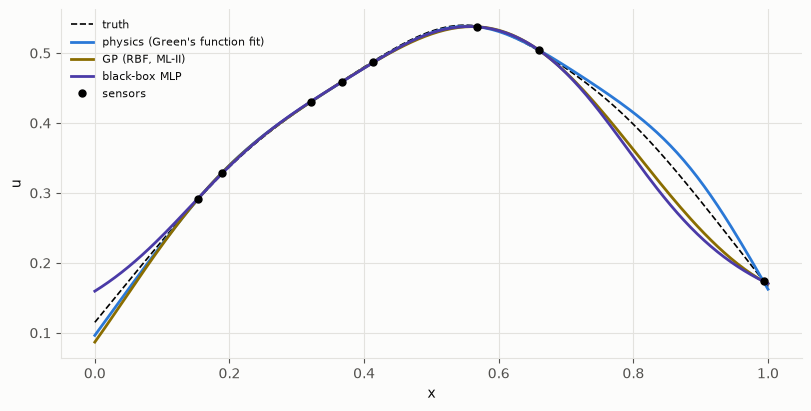

physics  nRMSE 0.0902
gp       nRMSE 0.1504
nn       nRMSE 0.1921
true sources      [0.208 0.55  0.793]
recovered sources [0.193 0.554 0.889]


In [2]:
seed = 11
sc = make_scene(F.draw_field("box", 1, seed))
x, y, _ = F.sensors(sc.field, 8, seed, NOISE, sc.scale)
fits = {
    "physics": M.fit_physics(x, y, sc.field.geom, seed=seed),
    "gp": M.fit_gp(x, y),
    "nn": M.fit_nn(x, y, cfg=nn_cfg(1), seed=seed, epochs=2500),
}
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(sc.X[:, 0], sc.truth, "k--", lw=1.2, label="truth")
for m, f in fits.items():
    ax.plot(sc.X[:, 0], f.predict(sc.X), color=RP.COLOR[m], label=RP.LABEL[m])
ax.plot(x[:, 0], y, "ko", ms=5, label="sensors")
ax.set_xlabel("x"); ax.set_ylabel("u"); ax.legend(fontsize=8)
plt.show()
for m, f in fits.items():
    print(f"{m:8s} nRMSE {score(f, sc, x)['nrmse']:.4f}")
print("true sources     ", np.sort(sc.field.centers[:, 0]).round(3))
print("recovered sources", np.sort(fits["physics"].extra["centers"][:, 0]).round(3))

The physics fit returns the source positions as well as the field. The
generic methods return only the field.

## 2 · A plate

The same physics in two dimensions: twelve unknowns. With 32 sensors the
generic methods see roughly a 6 x 6 lattice, coarser than the source width.

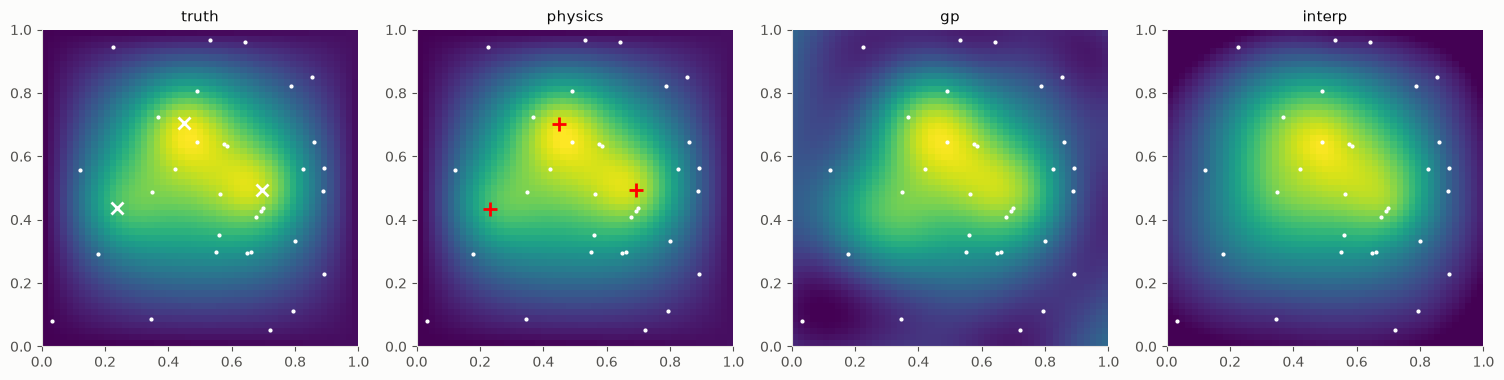

physics  nRMSE 0.0073
gp       nRMSE 0.2492
interp   nRMSE 0.1550


In [3]:
sc2 = make_scene(F.draw_field("box", 2, seed))
x, y, _ = F.sensors(sc2.field, 32, seed, NOISE, sc2.scale)
fits2 = {
    "physics": M.fit_physics(x, y, sc2.field.geom, seed=seed),
    "gp": M.fit_gp(x, y),
    "interp": M.fit_interp(x, y, smoothing=tuned["interp"]["box"]["2"] if tuned else 0.0),
}
m2 = int(round(np.sqrt(len(sc2.X))))
fig, axes = plt.subplots(1, 4, figsize=(15, 3.6))
panels = [("truth", sc2.truth)] + [(m, f.predict(sc2.X)) for m, f in fits2.items()]
for ax, (t, v) in zip(axes, panels):
    ax.imshow(v.reshape(m2, m2).T, origin="lower", extent=(0, 1, 0, 1),
              vmin=sc2.truth.min(), vmax=sc2.truth.max(), cmap="viridis")
    ax.plot(x[:, 0], x[:, 1], "w.", ms=4); ax.grid(False); ax.set_title(t)
axes[0].plot(*sc2.field.centers.T, "wx", ms=9, mew=2)
axes[1].plot(*fits2["physics"].extra["centers"].T, "r+", ms=10, mew=2)
plt.show()
for m, f in fits2.items():
    print(f"{m:8s} nRMSE {score(f, sc2, x)['nrmse']:.4f}")

## 3 · A potential in three dimensions

Three charges of mixed sign in free space; the Green's function is the
(smoothed) $1/4\pi r$. The sensors fill the unit cube, and the field is
also scored on the shell around it out to $[-0.5, 1.5]^3$, where no sensor
has been. That is extrapolation.

physics  inside the cube 0.0033   outside 0.0030
gp       inside the cube 0.2617   outside 0.7351


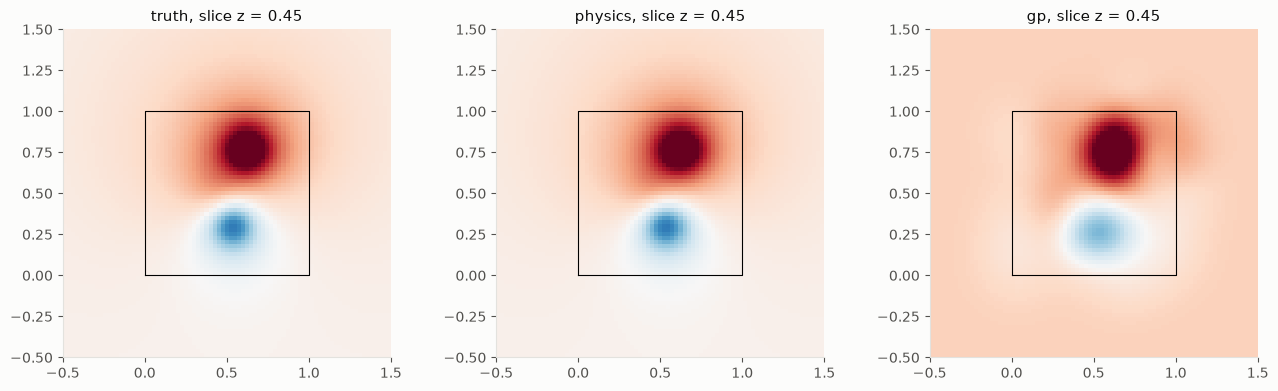

In [4]:
sc3 = make_scene(F.draw_field("free", 3, seed))
x, y, _ = F.sensors(sc3.field, 128, seed, NOISE, sc3.scale)
fits3 = {"physics": M.fit_physics(x, y, sc3.field.geom, seed=seed), "gp": M.fit_gp(x, y)}
for m, f in fits3.items():
    s = score(f, sc3, x)
    print(f"{m:8s} inside the cube {s['nrmse_in']:.4f}   outside {s['nrmse_out']:.4f}")

g = np.linspace(-0.5, 1.5, 81)
zc = sc3.field.centers[0, 2]
P2 = np.stack(np.meshgrid(g, g, indexing="ij"), -1).reshape(-1, 2)
P3 = np.column_stack([P2, np.full(len(P2), zc)])
truth = sc3.field.value(P3)
fig, axes = plt.subplots(1, 3, figsize=(13, 3.8))
lim = np.percentile(np.abs(truth), 99)
for ax, (t, v) in zip(axes, [("truth", truth)] + [(m, f.predict(P3)) for m, f in fits3.items()]):
    ax.imshow(v.reshape(81, 81).T, origin="lower", extent=(-0.5, 1.5, -0.5, 1.5),
              vmin=-lim, vmax=lim, cmap="RdBu_r")
    ax.plot([0, 1, 1, 0, 0], [0, 0, 1, 1, 0], color="k", lw=0.8)
    ax.grid(False); ax.set_title(f"{t}, slice z = {zc:.2f}")
plt.show()

The square marks the sensor cube. Outside it the GP returns to its mean;
the physics fit carries the charges' far field.

## 4 · How many sensors, as a function of dimension?

The study (`physprior.reconstruction.study.run`) repeats this for N on a
log grid, three reporting seeds (new field and new sensors each) and both
field families, and records the N at which each method's median error first
reaches nRMSE 0.1. Where a method never reaches it, the value is a lower
bound, drawn as an open circle with an arrow. The dotted line is the number
of physical unknowns.

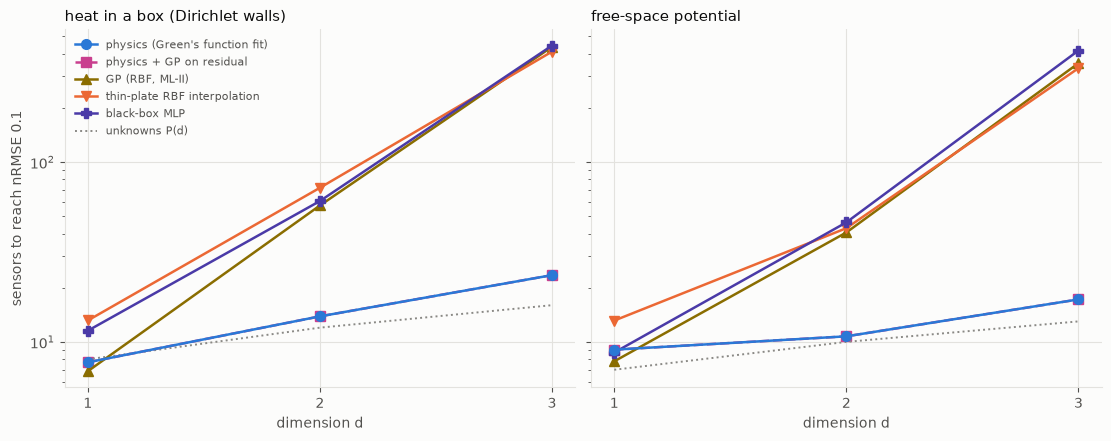

d                1     2      3
case method                    
box  gp        7.0  57.0  437.0
     interp   13.0  72.0  411.0
     nn       12.0  61.0  444.0
     physics   8.0  14.0   24.0
     pigp      8.0  14.0   24.0
free gp        8.0  41.0  354.0
     interp   13.0  43.0  332.0
     nn        9.0  46.0  417.0
     physics   9.0  11.0   17.0
     pigp      9.0  11.0   17.0

In [5]:
fig = RP.fig_samples_needed(0.1)
plt.show()
ns = load_table("reconstruction", "samples_needed")
ns[(ns.metric == "nrmse") & (ns.target == 0.1)].pivot_table(
    index=["case", "method"], columns="d", values="N_star").round(0)

In [6]:
json.loads((res / "verdict.json").read_text())

{'box': {'best_black_box_by_d': {'1': 'gp', '2': 'gp', '3': 'interp'},
  'black_box_3d_censored': False,
  'black_box_ratio_3d_1d': 59.832866458865084,
  'criterion_1_black_box_grows': True,
  'criterion_2_physics_tracks_unknowns': True,
  'criterion_3_gap_widens': True,
  'determinate': True,
  'gap_1d': 0.8922707680698502,
  'gap_3d': 17.491472687017975,
  'physics_N_star': {'1': 7.7001392862846245, '3': 23.502208751904348},
  'physics_censored': False,
  'physics_scaled_prediction_3d': 15.400278572569249,
  'supported': True},
 'free': {'best_black_box_by_d': {'1': 'gp', '2': 'gp', '3': 'interp'},
  'black_box_3d_censored': False,
  'black_box_ratio_3d_1d': 42.622810013838524,
  'criterion_1_black_box_grows': True,
  'criterion_2_physics_tracks_unknowns': True,
  'criterion_3_gap_widens': True,
  'determinate': True,
  'gap_1d': 0.8615598132902657,
  'gap_3d': 19.297887441744447,
  'physics_N_star': {'1': 9.052096427027928, '3': 17.225304757096538},
  'physics_censored': False,
  'p

The verdict applies the three criteria written down before the study ran
(`docs/reconstruction/HYPOTHESIS.md`).

## 5 · When the physics model is incomplete

The physics fit is only as good as its model. In the plate, the truth now has
either a fourth, weaker source the model does not know about, or an
insulated wall the model treats as held at a fixed temperature. The physics
fit then stops improving at an error floor. A GP fitted to the physics
residual (`pigp`) is a learned correction on top of the incomplete law.

physics  nRMSE 0.0538
pigp     nRMSE 0.0125
gp       nRMSE 0.0292


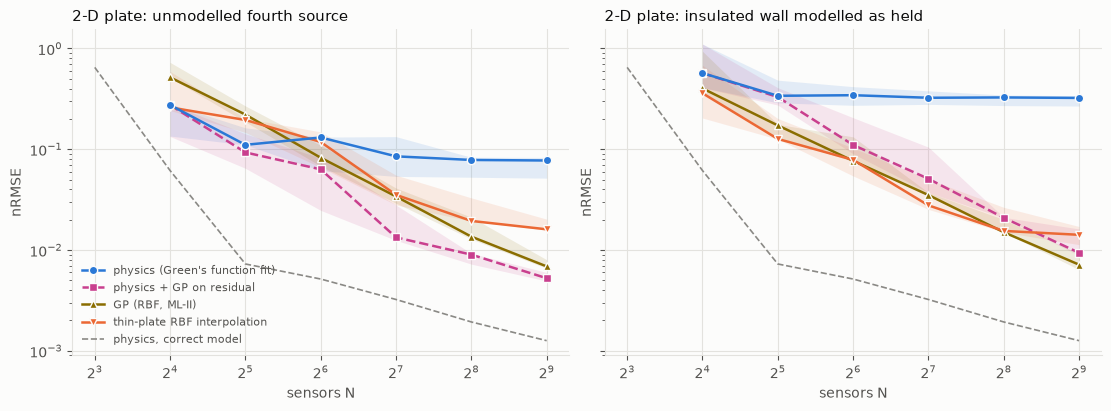

In [7]:
f = F.mismatch_field("extra_source", seed)
scm = make_scene(f)
x, y, _ = F.sensors(f, 128, seed, NOISE, scm.scale)
ph = M.fit_physics(x, y, f.geom, seed=seed)
pg = M.fit_gp(x, y, mean=ph.predict, name="pigp")
gp = M.fit_gp(x, y)
for name, fit in [("physics", ph), ("pigp", pg), ("gp", gp)]:
    print(f"{name:8s} nRMSE {score(fit, scm, x)['nrmse']:.4f}")
fig = RP.fig_mismatch()
plt.show()

## What to take from this

- The generic methods' sensor requirement is set by how finely they must
  sample the domain, which grows with dimension. The physics fit's is set by
  its unknowns.
- The physics fit also answers a question the others cannot: where the
  sources are.
- With an incomplete model the physics fit has an error floor, and a
  learned correction on its residual is how to get below it. The full tables,
  including the noise sweep, the PINN and the solver convergence studies,
  are on `docs/reconstruction/README.md`.